In [1]:
%pip install emoji

   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---

In [6]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install beautifulsoup4
%pip install wordcloud
%pip install textblob
%pip install nltk
%pip install scikit-learn
%pip install seaborn
%pip install emoji


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ----------------------------

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from wordcloud import WordCloud
import re
import string
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
import emoji
nltk.download('punkt')
nltk.download('wordnet')
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from nltk.stem import PorterStemmer
import re
import seaborn as sns

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Samsung\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Samsung\AppData\Roaming\nltk_data...


In [8]:
df = pd.read_csv('./spam.csv', encoding='latin-1')

In [9]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.shape

(5572, 2)

In [11]:
df.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [12]:
df.isnull()

,Category,Message
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
5567,False,False
5568,False,False
5569,False,False
5570,False,False


In [13]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [14]:
df.duplicated().sum()

415

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

0

In [17]:
#find duplicates and drop (inplace=True)
df.drop_duplicates(inplace=True)

In [18]:
print(df.duplicated().any())

False


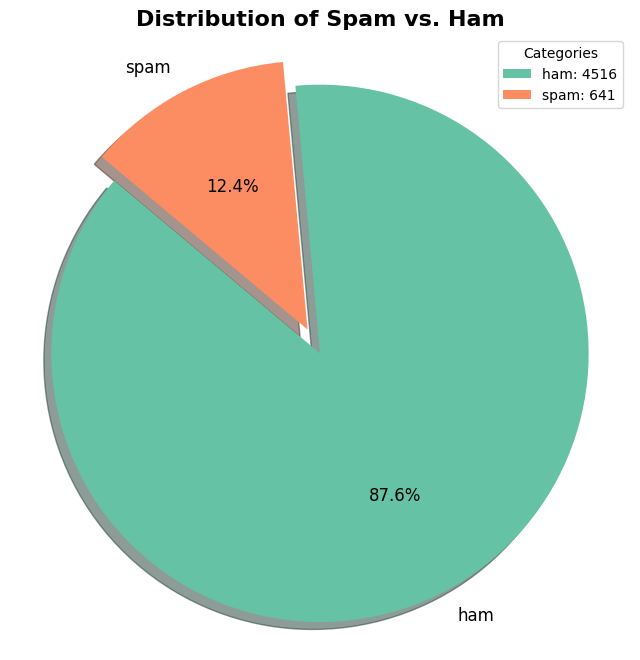

In [19]:
# Calculate the count of each label
category_counts = df['Category'].value_counts()

# Custom colors (seaborn palette)
colors = sns.color_palette("Set2", len(category_counts))

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=[0.05] * len(category_counts),  # Slight separation
    shadow=True,
    textprops={'fontsize': 12}
)

plt.title('Distribution of Spam vs. Ham', fontsize=16, fontweight='bold')
plt.axis('equal')  # Ensures a perfect circle
plt.legend(
    [f"{label}: {count}" for label, count in zip(category_counts.index, category_counts)],
    title="Categories",
    loc="upper right",
    fontsize=10
)
plt.show()

**TEXT VISUALIZATION**

Loop through each category

Go through every unique value in the Category column (e.g., Spam, Ham).

Filter the dataset for that category

Pick only the rows that belong to the current category and store them in a new DataFrame.

Combine all messages

Join all the text from the Message column of the filtered DataFrame into one big string.

Create a word cloud

Use this combined text to generate a word cloud, setting its width, height, and background color.

In the word cloud, the more often a word appears, the larger it looks.

Display the word cloud

Plot the generated word cloud with Matplotlib.

Add the category name as the title.

Hide the axes for a cleaner look.

C:\Users\Samsung\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


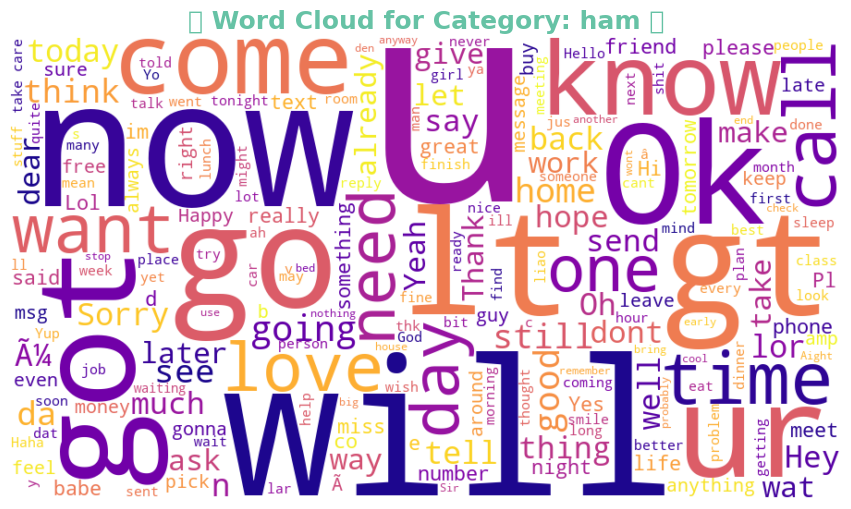

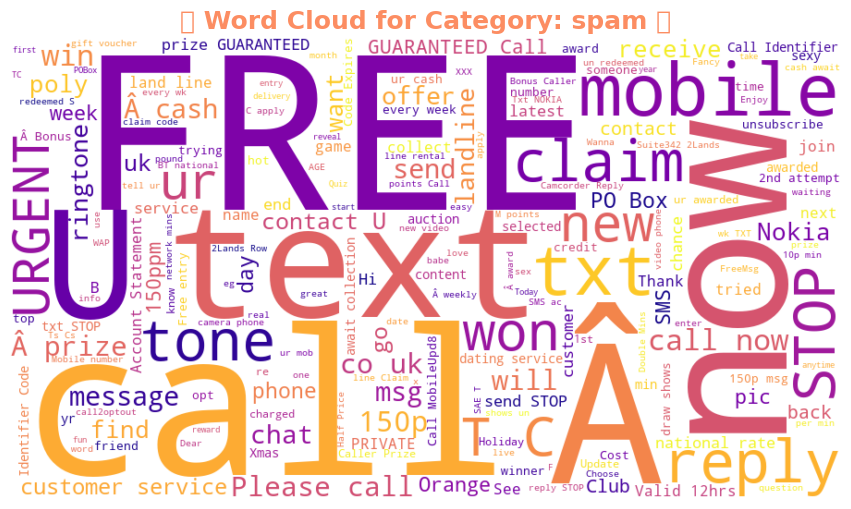

In [20]:
# Custom color palette for categories
palette = sns.color_palette("Set2", len(df['Category'].unique()))
colors = {cat: palette[i] for i, cat in enumerate(df['Category'].unique())}

# Iterate through unique categories
for category in df['Category'].unique():
    # Filter the DataFrame for the current category
    filtered_df = df[df['Category'] == category]

    # Concatenate all text data for the current category
    text = ' '.join(filtered_df['Message'])

    # Generate word cloud
    wordcloud = WordCloud(
        width=900,
        height=500,
        background_color='white',
        colormap='plasma',    # colorful words
        max_words=200,
        contour_color=colors[category],  # border in category color
        contour_width=2
    ).generate(text)

    # Plot the word cloud
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'✨ Word Cloud for Category: {category} ✨',
              fontsize=18, fontweight='bold', color=colors[category])
    plt.axis('off')
    plt.show()

In [21]:
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])

**TEXT PREPROCESSING**

Lower Casing

Remove Extra White Spaces

Remove HTML Tags

Remove URLs

Remove Punctuations

Remove Special Characters

Remove Numeric Values

Remove Non-alpha Numeric

Handling StopWords

Handling Emojis

Stemming

In [22]:
df['Message'] = df['Message'].str.lower()
df.head()

,Category,Message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [23]:
from bs4 import BeautifulSoup

In [24]:
# Function to clean text by removing HTML tags, scripts, and styles
def clean_html(text: str) -> str:
    """Remove HTML tags, <script>, and <style> content from text."""
    soup = BeautifulSoup(text, "html.parser")

    # Remove unwanted elements
    for element in soup(["script", "style"]):
        element.extract()

    # Return cleaned text
    return ' '.join(soup.stripped_strings)

# Apply cleaning function to the 'Message' column
df['Message'] = df['Message'].apply(clean_html)


In [25]:
# Remove extra white spaces from the 'Text' column
df['Message'] = df['Message'].str.strip()
df.head()


,Category,Message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [26]:
# Define a function to remove URLs using regular expressions
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    cleaned_text = url_pattern.sub('', text)
    return cleaned_text



# Apply the function to the 'Text' column
df['Message'] = df['Message'].apply(remove_urls)
df.head(10)

,Category,Message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."
5,1,freemsg hey there darling it's been 3 week's n...
6,0,even my brother is not like to speak with me. ...
7,0,as per your request 'melle melle (oru minnamin...
8,1,winner!! as a valued network customer you have...
9,1,had your mobile 11 months or more? u r entitle...


In [27]:
# Function to remove special characters and keep only letters, numbers, and spaces
def clean_special_characters(text: str) -> str:
    """Remove all characters from text except alphabets, numbers, and whitespace."""
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

# Apply the cleaning function to the 'Message' column
df['Message'] = df['Message'].apply(clean_special_characters)

# Preview the first 10 rows
df.head(10)

,Category,Message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...
5,1,freemsg hey there darling its been 3 weeks now...
6,0,even my brother is not like to speak with me t...
7,0,as per your request melle melle oru minnaminun...
8,1,winner as a valued network customer you have b...
9,1,had your mobile 11 months or more u r entitled...


In [28]:
# Function to remove numeric values from text
def remove_numbers(text: str) -> str:
    """Remove all numeric digits from the given text."""
    return re.sub(r'\d+', '', text)

# Apply the function to the 'Message' column
df['Message'] = df['Message'].apply(remove_numbers)

# Preview the DataFrame
df.head(8)

,Category,Message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup final...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...
5,1,freemsg hey there darling its been weeks now ...
6,0,even my brother is not like to speak with me t...
7,0,as per your request melle melle oru minnaminun...


In [29]:
# Define a function to remove non-alphanumeric characters
def remove_non_alphanumeric(text):
    non_alpha_text = re.sub(r'[^a-zA-Z]\s', '', text)
    return non_alpha_text

# Apply the function to the "Message" column
df['Message'] = df['Message'].apply(remove_non_alphanumeric)

df.head(10)


,Category,Message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry ina wkly comp to win fa cup final t...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...
5,1,freemsg hey there darling its beenweeks now an...
6,0,even my brother is not like to speak with me t...
7,0,as per your request melle melle oru minnaminun...
8,1,winner as a valued network customer you have b...
9,1,had your mobilemonths or more u r entitled to ...


In [30]:

# Define a dictionary of chat word mappings
chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing"
}

In [31]:


# Function to replace chat words with their full forms
def replace_chat_words(text):
    for abbr, fullform in chat_words.items():
      text = text.replace(abbr, fullform)
    return text

# Apply replace_chat_words function to 'Text' column
df['Message'] = df['Message'].apply(replace_chat_words)
df.head(10)

,Category,Message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry ina wkly comp to win fa cup final t...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...
5,1,freemsg hey there darling its beenweeks now an...
6,0,even my brother is not like to speak with me t...
7,0,as per your request melle melle oru minnaminun...
8,1,winner as a valued network customer you have b...
9,1,had your mobilemonths or more u r entitled to ...


In [32]:
# Download NLTK stopwords corpus
nltk.download('stopwords')

# Get English stopwords from NLTK
stop_words = set(stopwords.words('english'))

# Function to remove stop words from text
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Apply remove_stopwords function to 'Text' column
df['Message'] = df['Message'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Samsung\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [33]:
# Function to remove emojis from text
def remove_emojis(text):
    return emoji.demojize(text)

# Apply remove_emojis function to 'Text' column
df['Message'] = df['Message'].apply(remove_emojis)

In [34]:

# Initialize the Porter Stemmer
porter_stemmer = PorterStemmer()

# Apply stemming
df['Message_stemmed'] = df['Message'].apply(lambda x: ' '.join([porter_stemmer.stem(word) for word in x.split()]))
df.head()


,Category,Message,Message_stemmed
0,0,go jurong point crazy available bugis n great ...,go jurong point crazi avail bugi n great world...
1,0,ok lar joking wif u oni,ok lar joke wif u oni
2,1,free entry ina wkly comp win fa cup final tkts...,free entri ina wkli comp win fa cup final tkt ...
3,0,u dun say early hor u c already say,u dun say earli hor u c alreadi say
4,0,nah dont think goes usf lives around though,nah dont think goe usf live around though


In [35]:
#Convert text to numbers using bag of words
# vectorizer=CountVectorizer()
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X=vectorizer.fit_transform(df['Message_stemmed']).toarray()
y = df['Category']


Beginning with the training and testing of the model

In [36]:
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 51)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
y_train

5305    0
4553    0
2372    0
5003    0
3389    0
       ..
4266    0
1796    0
1823    0
494     0
2194    0
Name: Category, Length: 4125, dtype: int32

Writing logistic regression from scratch

In [39]:
import numpy as np

class LRScratch:
    def __init__(self, learning_rate=0.01, epochs=1000, reg_strength=0.0):
        """Logistic Regression from scratch with optional L2 regularization."""
        self.lr = learning_rate
        self.epochs = epochs
        self.reg_strength = reg_strength
        self.losses = []
        self.weights = None
        self.bias = 0.0

    def sigmoid(self, z):
        """Apply sigmoid function."""
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        """Train model using gradient descent."""
        self.m, self.n = X.shape
        self.weights = np.zeros(self.n)
        self.bias = 0.0

        for _ in range(self.epochs):
            # Forward pass
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # Gradients with regularization
            dw = (1 / self.m) * np.dot(X.T, (y_pred - y)) + (self.reg_strength / self.m) * self.weights
            db = (1 / self.m) * np.sum(y_pred - y)

            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Compute loss (with epsilon for numerical stability)
            epsilon = 1e-9
            loss = -(1 / self.m) * np.sum(
                y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon)
            )
            self.losses.append(loss)

    def predict(self, X):
        """Predict binary labels."""
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred > 0.5).astype(int)

CountVectorizer()

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = LRScratch(learning_rate=0.01, epochs=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9689922480620154
Precision: 0.8602941176470589
Recall: 0.9
F1 Score: 0.8796992481203008
Confusion Matrix:
 [[883  19]
 [ 13 117]]


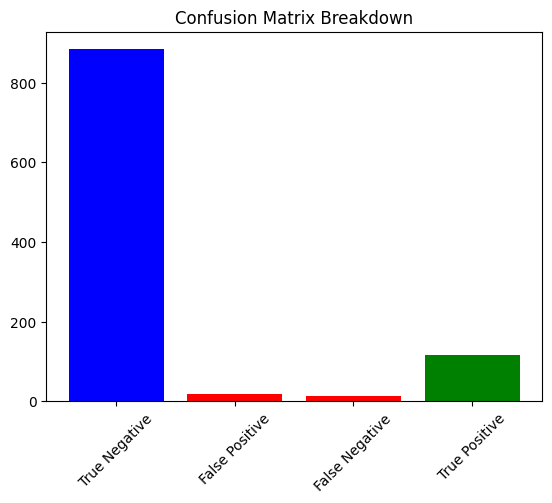

In [41]:
cm = confusion_matrix(y_test, y_pred)
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]

counts = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
plt.bar(labels, counts, color=['blue','red','red','green'])
plt.xticks(rotation=45)
plt.title("Confusion Matrix Breakdown")
plt.show()

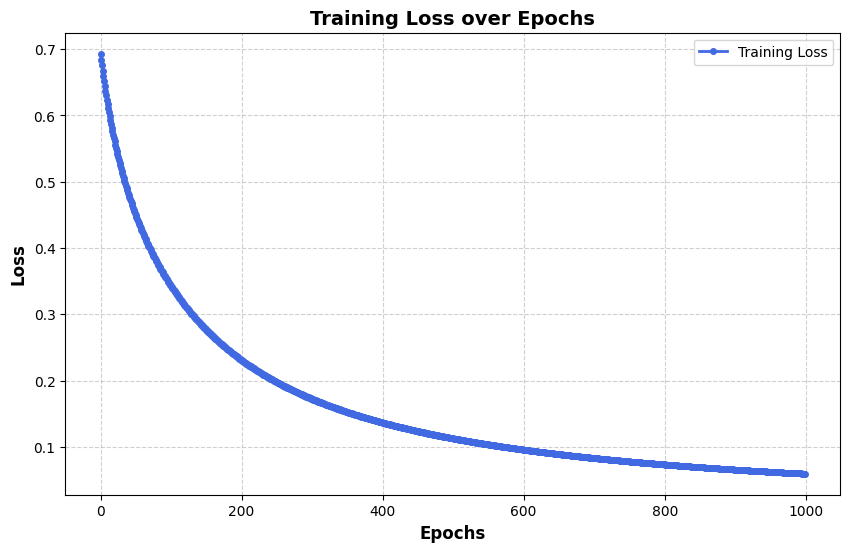

In [42]:
plt.figure(figsize=(10, 6))  # bigger figure

# plot line with color + thickness + marker
plt.plot(range(len(model.losses)), model.losses,
         color="royalblue", linewidth=2, marker="o", markersize=4, label="Training Loss")

# labels + title
plt.xlabel("Epochs", fontsize=12, fontweight="bold")
plt.ylabel("Loss", fontsize=12, fontweight="bold")
plt.title("Training Loss over Epochs", fontsize=14, fontweight="bold")

# grid + legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# make ticks more readable
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = LRScratch(learning_rate=0.01, epochs=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9689922480620154
Precision: 0.8602941176470589
Recall: 0.9
F1 Score: 0.8796992481203008
Confusion Matrix:
 [[883  19]
 [ 13 117]]


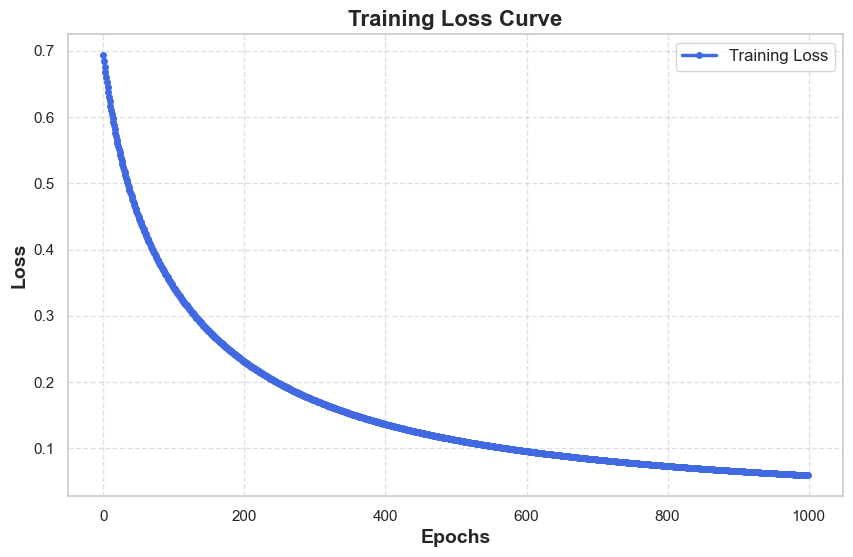

In [44]:
sns.set(style="whitegrid")

# Plot loss curve
plt.figure(figsize=(10, 6))
plt.plot(
    range(len(model.losses)),
    model.losses,
    color="royalblue",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Training Loss"
)

# Add labels and title
plt.xlabel("Epochs", fontsize=14, fontweight="bold")
plt.ylabel("Loss", fontsize=14, fontweight="bold")
plt.title("Training Loss Curve", fontsize=16, fontweight="bold")

# Add legend and grid
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

**Training the model using sklearn**

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Message_stemmed']).toarray()
y = df['Category']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [48]:
scaler = StandardScaler(with_mean=False)   # use with_mean=False because sparse matrix
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
model = LogisticRegression(max_iter=1080)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1080
,multi_class,'deprecated'


In [50]:
y_pred = model.predict(X_test_scaled)

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9573643410852714
Precision: 0.967479674796748
Recall: 0.6574585635359116
F1 Score: 0.7828947368421053
Confusion Matrix:
 [[1363    4]
 [  62  119]]


In [52]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class LogisticRegression:
    def __init__(self, lr=0.01, k=0.002):
        self.lr = lr
        self.k = k

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def hypothesis(self, X, w, w0):
        return self.sigmoid(X @ w + w0)

    def loss(self, X, w, w0, y):
        ypred = self.hypothesis(X, w, w0)
        eps = 1e-9
        return -np.mean(y*np.log(ypred + eps) + (1-y)*np.log(1-ypred + eps)) + (self.k/2) * np.sum(w**2)

    def gradientDescent(self, X, y, lr=0.01, epochs=100):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float).reshape(-1)

        w = np.zeros(X.shape[1])
        w0 = 0
        self.loss_e = [self.loss(X, w, w0, y)]

        for e in range(epochs):
            ypred = self.hypothesis(X, w, w0)

            dw = (X.T @ (ypred - y)) / len(y) + self.k * w
            dw0 = np.mean(ypred - y)

            w -= lr * dw
            w0 -= lr * dw0

            self.loss_e.append(self.loss(X, w, w0, y))

        self.w, self.w0 = w, w0
        return w, w0

    def fit(self, X, y, epochs=100):
        self.gradientDescent(X, y, self.lr, epochs)

    def predict_proba(self, X):
        X = np.array(X, dtype=float)
        return self.hypothesis(X, self.w, self.w0)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


Accuracy: 0.977390180878553
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1367
           1       0.95      0.86      0.90       181

    accuracy                           0.98      1548
   macro avg       0.96      0.92      0.94      1548
weighted avg       0.98      0.98      0.98      1548



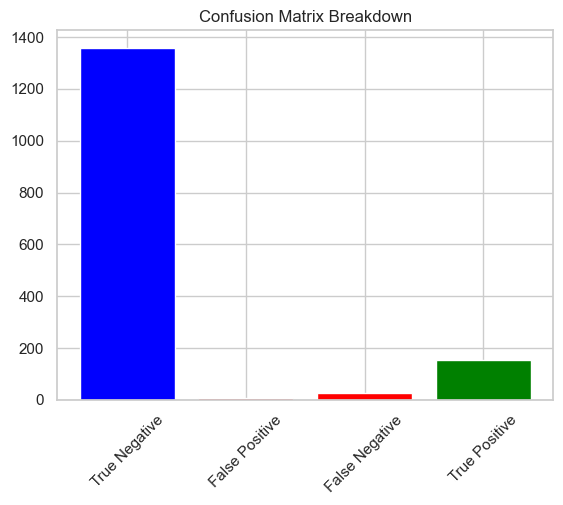

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Initialize and train
model = LogisticRegression(lr=0.05, k=0.001)
model.fit(X_train, y_train, epochs=1000)

# Predict
ypred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, ypred)
print("Accuracy:", acc)

# Classification report
print(classification_report(y_test, ypred))

# Confusion matrix plot
cm = confusion_matrix(y_test, ypred)
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
counts = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]

plt.bar(labels, counts, color=['blue','red','red','green'])
plt.xticks(rotation=45)
plt.title("Confusion Matrix Breakdown")
plt.show()


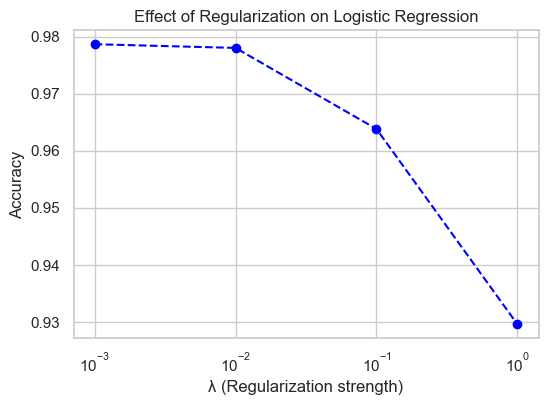

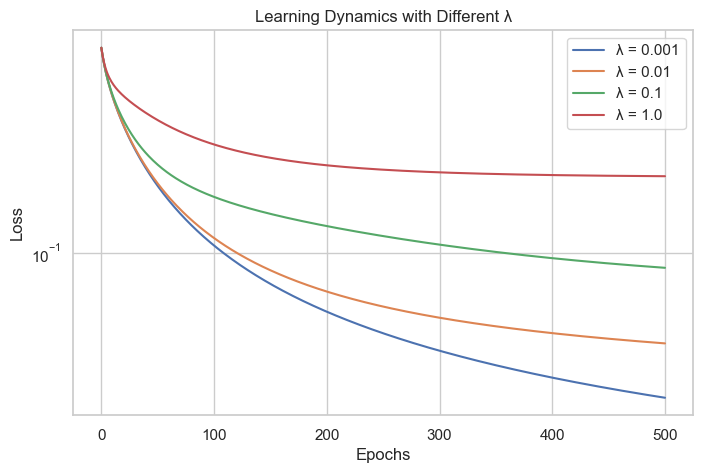

In [54]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Try wider lambda values
lambdas = [0.001, 0.01, 0.1, 1.0]
accuracies = []
loss_curves = {}

for lam in lambdas:
    model = LogisticRegression(lr=0.05, k=lam)
    model.fit(X_train, y_train, epochs=500)

    ypred = model.predict(X_test)
    acc = accuracy_score(y_test, ypred)
    accuracies.append(acc)

    loss_curves[lam] = model.loss_e

# --- Accuracy comparison ---
plt.figure(figsize=(6,4))
plt.plot(lambdas, accuracies, marker='o', linestyle='--', color='blue')
plt.xlabel("λ (Regularization strength)")
plt.ylabel("Accuracy")
plt.title("Effect of Regularization on Logistic Regression")
plt.xscale("log")  # log scale for λ
plt.show()

# --- Loss curves (better scaling) ---
plt.figure(figsize=(8,5))
for lam in lambdas:
    plt.plot(loss_curves[lam], label=f"λ = {lam}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")   # log scale to separate curves
plt.title("Learning Dynamics with Different λ")
plt.legend()
plt.show()
